In [2]:
from llrf_app.app import LLRFApp
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import signal
import time

plt.rcParams['figure.figsize'] = [6, 4]
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.which'] = "both"
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['font.size'] = 8

%load_ext autoreload
%autoreload 2

In [3]:
def calc_ps(wfm, title='', fullscale=32767, fs_mhz=115):
    fsdb = 20 * np.log10(fullscale / np.sqrt(2))
    f, pxx = signal.periodogram(
        wfm, fs_mhz, 'flattop', scaling='spectrum', nfft=8192)
    psd_dbfs = 10 * np.log10(pxx) - fsdb
    return f, psd_dbfs

def plot_ps(f, psd_dbfs, title='', annotate=False):
    fig, ax = plt.subplots()
    ax.set_xlabel('Freq [MHz]')
    ax.set_ylabel('Mag [dBFS]')
    ax.set_ylim(-120, 0)
    ax.set_title(title)
    if len(psd_dbfs.shape) == 1:
        ax.plot(f, psd_dbfs)
        if annotate:
            idx = np.argmax(psd_dbfs)
            pwr = psd_dbfs[idx]
            ax.annotate(
                f'{f[idx]:5.3f}  MHz\n {pwr:5.3f} dBFS',
                xy=(f[idx], pwr), xytext=(1, -20),
                arrowprops=dict(shrink=0.05))
    elif len(psd_dbfs.shape) == 2:   # plot psd array
        for ix, p in enumerate(psd_dbfs):
            ax.plot(f, p, label='adc' + str(ix))
        ax.legend()

# Read Board Support info

In [4]:
llrf = LLRFApp(addr='192.168.19.42:803', conf='LEMP', chan_keep=1)
llrf.get_bsp_info()

Marble Variant: V1.3
ADN4600 U2:
  IN 2 -> OUT 0
  IN 3 -> OUT 1
  IN 2 -> OUT 2
  IN 3 -> OUT 3
INA219 U57, 12V:
  Vshunt     :    -20.1 mV
  Power      :      6.3 mW
  Vbus       :     11.8 V
  Current    :  -1027.2 mA
INA219 U17, FMC1:
  Vshunt     :    -28.7 mV
  Power      :     49.5 mW
  Vbus       :     11.8 V
  Current    :    183.8 mA
INA219 U32, FMC2:
  Vshunt     :    -19.9 mV
  Power      :     41.9 mW
  Vbus       :     11.8 V
  Current    :    139.3 mA
 PCA9555 U34, QSFP:
  I0         :    01111111
  I1         :    01001111
 PCA9555 U39, MISC:
  I0         :    11111110
  I1         :    11110011
QSFP 2 is present:
  Vendor     :    AVAGO           
  Part       :    AFBR-79EQDZ     
  Serial     :    QH3201VZ        
  TXRX_LOS   :    11110000
  Temp       :    48 C
  Volt       :    3260 mV
  TxBias0    :    0 uA
  TxPwr0     :    0 uW
  RxPwr0     :    659 uW
  TxBias1    :    0 uA
  TxPwr1     :    0 uW
  RxPwr1     :    683 uW
  TxBias2    :    0 uA
  TxPwr2     :  

Measure a snapshot of RF amplitude and phases

In [5]:
llrf.reg_write([
    ('amp_setpoint', 25833 * 2),
    ('phs_setpoint', 0),
    ('inlk_permit_mask', 0),
    ('dac_permit', 1),
    ('pulse_mode', 0)
])
time.sleep(0.1)
raw_wfms = llrf.read_raw_bufs()
adc_wfm = raw_wfms[:8]
dac_wfm = raw_wfms[8:10]

In [6]:
df_mon = llrf.get_rfmon()
df_mon

,mon_amp,mon_phs,Amp [cnt],Phs [deg]
ADC0,3796,-26093,6368.689402,-71.666565
ADC1,713,-12305,1196.226434,-33.796692
ADC2,2,-32458,3.355474,-89.148560
ADC3,11786,-20,19773.807507,-0.054932
ADC4,2,-65226,3.355474,-179.148560
ADC5,2,-32458,3.355474,-89.148560
ADC6,2,-49138,3.355474,-134.961548
ADC7,2,-32458,3.355474,-89.148560
DAC0,11919,-3,19996.946519,-0.008240
DAC1,11919,-3,19996.946519,-0.008240


Confirm MO phase is aligned

In [7]:
assert -0.1 < df_mon['Phs [deg]']['ADC3'] < 0.1

## Plot raw DAC / ADC data

In [8]:
df_dac = pd.DataFrame(dac_wfm.T, columns=[f'dac{n}' for n in range(2)])
df_dac['Time [ns]'] = np.arange(dac_wfm.shape[-1]) * llrf.DSP_CLK_CYCLE
df_dac.set_index('Time [ns]', inplace=True)

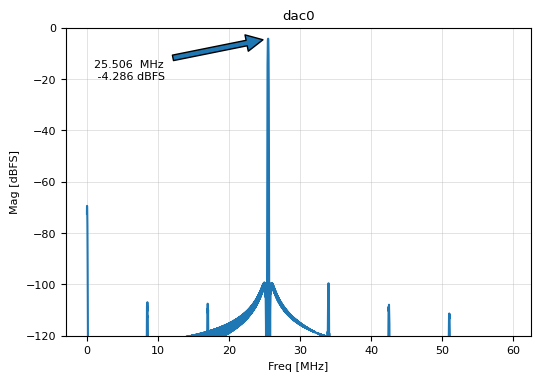

In [9]:
f, psd_dbfs = calc_ps(df_dac['dac0'], fs_mhz=1e3/llrf.DSP_CLK_CYCLE)
plot_ps(f, psd_dbfs, title='dac0', annotate=True)

In [10]:
df = pd.DataFrame(adc_wfm.T, columns=[f'adc{n}' for n in range(8)])
df['Time [ns]'] = np.arange(adc_wfm.shape[-1]) * llrf.DSP_CLK_CYCLE
df.set_index('Time [ns]', inplace=True)

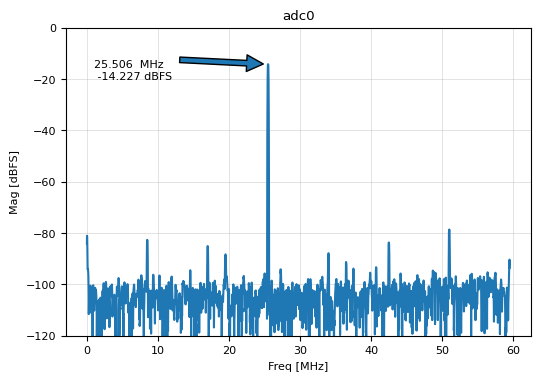

In [11]:
f, psd_dbfs = calc_ps(df['adc0'], fs_mhz=1e3/llrf.DSP_CLK_CYCLE)
plot_ps(f, psd_dbfs, title='adc0', annotate=True)

# Pulse mode test

In [12]:
# generate 4µs pulse
pulse_high_len = int(4000 / llrf.DSP_CLK_CYCLE  / llrf.CIC_BASE_PERIOD)
llrf.reg_write([
    ('pulse_high_len', pulse_high_len),
    ('pulse_mode', 1)
])
time.sleep(0.5)

print(f'pulse_high_len: {pulse_high_len} counts')

pulse_high_len: 16 counts


In [13]:
def read_raw_adcs():
    adc_wfm = llrf.read_adc_bufs()
    df = pd.DataFrame(adc_wfm.T, columns=[f'adc{n}' for n in range(8)])
    df['Time [ns]'] = np.arange(adc_wfm.shape[-1]) * llrf.DSP_CLK_CYCLE
    df.set_index('Time [ns]', inplace=True)
    return df

<Axes: xlabel='Time [ns]'>

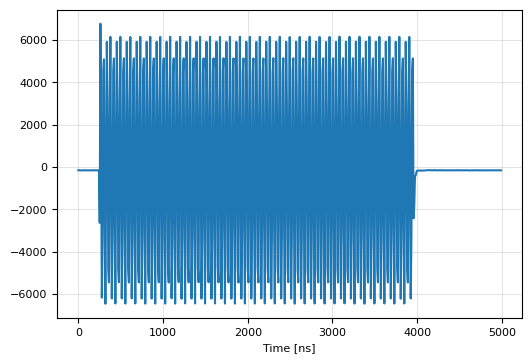

In [14]:
df = read_raw_adcs()['adc0']
df.loc[:5000].plot()

In [18]:
adc0_iq_wfm = llrf.read_iq_wfm('adc0')

<Axes: xlabel='Time [ns]'>

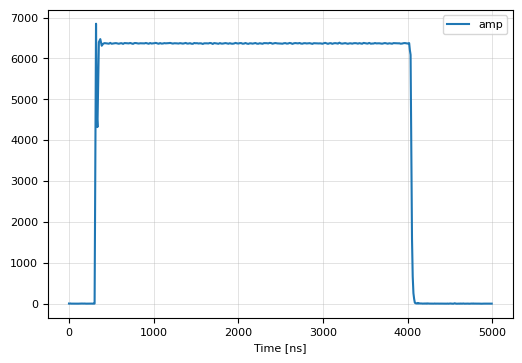

In [19]:
df = pd.DataFrame(adc0_iq_wfm.T, columns=['iq'])
df['Time [ns]'] = np.arange(adc0_iq_wfm.shape[-1]) * llrf.DSP_CLK_CYCLE
df.set_index('Time [ns]', inplace=True)
df['amp'] = np.abs(df['iq'])
df['phs'] = np.angle(df['iq'], deg=True)
df[['amp']].loc[:5000].plot()

<Axes: xlabel='Time [ns]'>

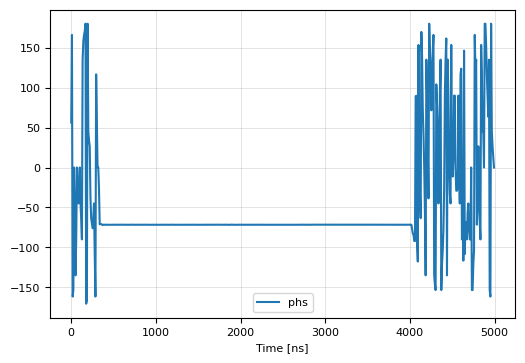

In [20]:
df[['phs']].loc[:5000].plot()

<Axes: xlabel='Time [ns]'>

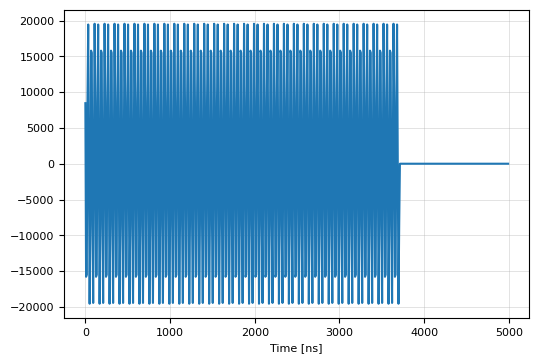

In [30]:
def read_raw_dacs():
    adc_wfm = llrf.read_dac_bufs()
    df = pd.DataFrame(adc_wfm.T, columns=[f'dac{n}' for n in range(2)])
    df['Time [ns]'] = np.arange(adc_wfm.shape[-1]) * llrf.DSP_CLK_CYCLE
    df.set_index('Time [ns]', inplace=True)
    return df
df = read_raw_dacs()['dac0']
df.loc[:5000].plot()

<Axes: xlabel='Time [ns]'>

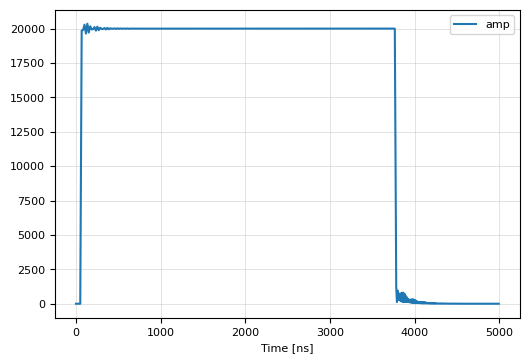

In [26]:
dac0_iq_wfm = llrf.read_iq_wfm('dac0')

df = pd.DataFrame(dac0_iq_wfm.T, columns=['iq'])
df['Time [ns]'] = np.arange(dac0_iq_wfm.shape[-1]) * llrf.DSP_CLK_CYCLE
df.set_index('Time [ns]', inplace=True)
df['amp'] = np.abs(df['iq'])
df['phs'] = np.angle(df['iq'], deg=True)
df[['amp']].loc[:5000].plot()

<Axes: xlabel='Time [ns]'>

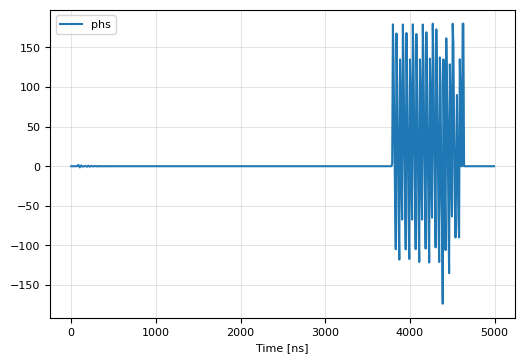

In [29]:
df[['phs']].loc[:5000].plot()

Verify IQ waveform signal gain:

In [21]:
amp = df[['amp']].loc[500:4000].values.mean()
phs = df[['phs']].loc[500:4000].values.mean()
print(f'IQ waveform signal: amp = {amp:8.3f} cnt, phs = {phs:8.3f} deg')

amp_exp = df_mon['Amp [cnt]']['ADC0']
phs_exp = df_mon['Phs [deg]']['ADC0']
print(f'Expected inlk_mon:  amp = {amp_exp:8.3f} cnt, '
      f'phs = {phs_exp:8.3f} deg')


IQ waveform signal: amp = 6367.672 cnt, phs =  -71.657 deg
Expected inlk_mon:  amp = 6368.689 cnt, phs =  -71.667 deg


## Plot circular buffer data

In [22]:
mp_traces = llrf.get_mp_wfm()

In [23]:
df_mp = pd.DataFrame(mp_traces.T, columns=['Amp [cnt]', 'Phase [deg]'])
df_mp['Time [ns]'] = np.arange(mp_traces.shape[-1]) * llrf.ts
df_mp.set_index('Time [ns]', inplace=True)

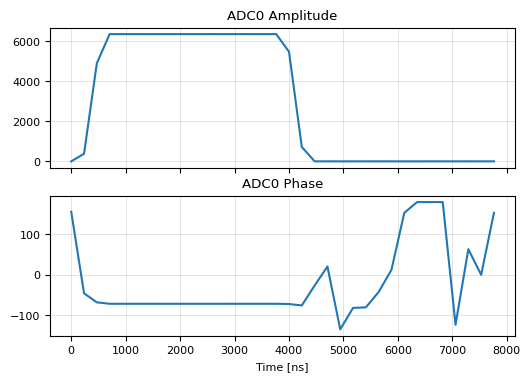

In [24]:
fig, axes = plt.subplots(2, sharex=True)
df_mp['Amp [cnt]'].loc[:8000].plot(title='ADC0 Amplitude', ax=axes[0]);
df_mp['Phase [deg]'].loc[:8000].plot(title='ADC0 Phase', ax=axes[1]);